In [1]:
from pathlib import Path
import re
import warnings

import MDAnalysis as mda
import numpy as np
import pandas as pd

from MDAnalysis.exceptions import NoDataError
from MDAnalysis.lib.distances import self_capped_distance


# -----------------------------------------------------------------------------


TRAJ_ROOT = Path("traj")
FRAGMENT_DIRS = [str(i) for i in range(1, 13)]


# ...
NC_SUBDIR = Path("centerizing/out_remove_center")

OUTPUT_DIR = Path("./interaction_outputs_by_fragment")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


#============================================================================= -----------------------------------------------------------------------------

NCHAINS = 64

# Heavy-atom minimum-distance cutoff
CUTOFF_A = 5.0

 
LAST_NS = 2000.0

# Analyze every frame.
# Increase to 5, 10, or 20 if the calculation is too slow.
FRAME_STRIDE = 1

# Use only the final 64 .nc files.
# Set to None to use all files.
MAX_NC_FILES_PER_FRAGMENT = 64

# True means take the LAST 64 files rather than the first 64.
USE_LAST_NC_FILES = True


 # FRAGMENT SIZES
# 
FRAG_CORE_RESIDUES = {
    1: 16,
    2: 16,
    3: 16,
    4: 16,
    5: 16,
    6: 16,
    7: 16,
    8: 16,
    9: 16,
    10: 16,
    11: 16,
    12: 15,
}

# Change these to 0 if ACE/NME caps are not present.
CAP_BEFORE = 1
CAP_AFTER = 1

# Includes ordinary protein residues and common terminal caps.
PEPTIDE_SELECTION = "protein or resname ACE NME NHE"


# -----------------------------------------------------------------------------

TOPOLOGY_BY_FRAGMENT = {
    # 1: Path("traj/1/your_no_water_topology.parm7"),
    # 2: Path("traj/2/your_no_water_topology.parm7"),
    # ...
}


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def natural_sort_key(path):
    """Natural sorting: file2.nc comes before file10.nc."""
    return [
        int(token) if token.isdigit() else token.lower()
        for token in re.split(r"(\d+)", path.name)
    ]


def find_nc_files(fragment_id):
    """Find and sort trajectory files for one fragment."""

    nc_dir = TRAJ_ROOT / str(fragment_id) / NC_SUBDIR

    if not nc_dir.exists():
        raise FileNotFoundError(
            f"Trajectory directory does not exist:\n{nc_dir}"
        )

    nc_files = sorted(
        nc_dir.glob("*.nc"),
        key=natural_sort_key,
    )

    if not nc_files:
        raise FileNotFoundError(
            f"No .nc files were found in:\n{nc_dir}"
        )

    if (
        MAX_NC_FILES_PER_FRAGMENT is not None
        and len(nc_files) > MAX_NC_FILES_PER_FRAGMENT
    ):
        if USE_LAST_NC_FILES:
            nc_files = nc_files[-MAX_NC_FILES_PER_FRAGMENT:]
        else:
            nc_files = nc_files[:MAX_NC_FILES_PER_FRAGMENT]

    return nc_files


def find_topology(fragment_id):
    """
    Locate a matching AMBER topology.

    Explicit paths in TOPOLOGY_BY_FRAGMENT take priority.
    """

    if fragment_id in TOPOLOGY_BY_FRAGMENT:
        topology = Path(TOPOLOGY_BY_FRAGMENT[fragment_id])

        if not topology.exists():
            raise FileNotFoundError(
                f"Specified topology does not exist:\n{topology}"
            )

        return topology

    fragment_dir = TRAJ_ROOT / str(fragment_id)

    preferred_patterns = [
        "**/*no_water*.parm7",
        "**/*nowater*.parm7",
        "**/*dry*.parm7",
        "**/*strip*.parm7",
        "**/*no_water*.prmtop",
        "**/*nowater*.prmtop",
        "**/*dry*.prmtop",
        "**/*strip*.prmtop",
    ]

    general_patterns = [
        "**/*.parm7",
        "**/*.prmtop",
    ]

    for patterns in (preferred_patterns, general_patterns):
        matches = []

        for pattern in patterns:
            matches.extend(fragment_dir.glob(pattern))

        matches = sorted(
            set(matches),
            key=lambda path: (len(path.parts), natural_sort_key(path)),
        )

        if len(matches) == 1:
            return matches[0]

        if len(matches) > 1:
            possible_files = "\n".join(
                f"  {path}" for path in matches
            )

            raise RuntimeError(
                f"Multiple topology files were found for Frag-{fragment_id}:\n"
                f"{possible_files}\n\n"
                "Specify the correct file in TOPOLOGY_BY_FRAGMENT."
            )

    raise FileNotFoundError(
        f"No .parm7 or .prmtop file was found under:\n{fragment_dir}"
    )


def load_universe(topology, nc_files):
    """Load a topology and sequential NetCDF files."""

    trajectory_paths = [str(path) for path in nc_files]

    try:
        return mda.Universe(
            str(topology),
            trajectory_paths,
            continuous=True,
        )

    except (TypeError, NotImplementedError):
        warnings.warn(
            "continuous=True was not accepted. "
            "Loading the trajectory files without it."
        )

        return mda.Universe(
            str(topology),
            trajectory_paths,
        )


def is_heavy_atom(atom_name):
    """
    Identify heavy atoms from AMBER atom names.

    Excludes names such as:
    H, HA, HB2, 1H, 2HG, etc.
    """

    return re.match(
        r"^[0-9]*H",
        str(atom_name).upper(),
    ) is None


def try_chain_attribute(peptide_atoms, attribute):
    """
    Try to identify chains from molnums, chainIDs, or segids.
    """

    try:
        values = np.asarray(
            getattr(peptide_atoms, attribute)
        )
    except (AttributeError, NoDataError):
        return None

    if values.dtype.kind in {"U", "S", "O"}:
        unique_values = [
            value
            for value in np.unique(values)
            if str(value).strip()
        ]
    else:
        unique_values = list(np.unique(values))

    if len(unique_values) != NCHAINS:
        return None

    value_to_chain = {
        value: chain_index
        for chain_index, value in enumerate(
            sorted(unique_values, key=str)
        )
    }

    heavy_mask = np.asarray(
        [is_heavy_atom(name) for name in peptide_atoms.names],
        dtype=bool,
    )

    heavy_atoms = peptide_atoms[heavy_mask]

    heavy_values = np.asarray(
        getattr(heavy_atoms, attribute)
    )

    atom_to_chain = np.asarray(
        [value_to_chain[value] for value in heavy_values],
        dtype=int,
    )

    return heavy_atoms, atom_to_chain


def build_chain_mapping(universe, fragment_id):
    """
    Map every peptide heavy atom to one of the 64 peptide chains.

    First tries topology chain identifiers.
    If unavailable, assumes residues are ordered chain-by-chain.
    """

    peptide_atoms = universe.select_atoms(PEPTIDE_SELECTION)

    if len(peptide_atoms) == 0:
        raise RuntimeError(
            f"No peptide atoms were selected for Frag-{fragment_id}.\n"
            f"Selection: {PEPTIDE_SELECTION}"
        )

    # Try topology-based chain identifiers.
    for attribute in ("molnums", "chainIDs", "segids"):
        result = try_chain_attribute(
            peptide_atoms,
            attribute,
        )

        if result is not None:
            heavy_atoms, atom_to_chain = result

            return (
                heavy_atoms,
                atom_to_chain,
                f"topology attribute: {attribute}",
            )

    # AMBER fallback: residues ordered chain-by-chain.
    residues_per_chain = (
        FRAG_CORE_RESIDUES[fragment_id]
        + CAP_BEFORE
        + CAP_AFTER
    )

    peptide_residues = peptide_atoms.residues

    expected_total_residues = (
        NCHAINS * residues_per_chain
    )

    if len(peptide_residues) != expected_total_residues:
        raise RuntimeError(
            f"Frag-{fragment_id}: chain identification failed.\n\n"
            f"Selected residues: {len(peptide_residues)}\n"
            f"Expected residues: {expected_total_residues}\n"
            f"Expected residues per chain: {residues_per_chain}\n\n"
            "Check FRAG_CORE_RESIDUES, CAP_BEFORE, CAP_AFTER, "
            "and PEPTIDE_SELECTION."
        )

    heavy_atom_indices = []
    atom_to_chain_list = []

    for chain_index in range(NCHAINS):
        first_residue = chain_index * residues_per_chain
        last_residue = first_residue + residues_per_chain

        chain_residues = peptide_residues[
            first_residue:last_residue
        ]

        chain_atoms = chain_residues.atoms

        chain_heavy_atoms = chain_atoms[
            np.asarray(
                [is_heavy_atom(name) for name in chain_atoms.names],
                dtype=bool,
            )
        ]

        heavy_atom_indices.extend(
            chain_heavy_atoms.indices.tolist()
        )

        atom_to_chain_list.extend(
            [chain_index] * len(chain_heavy_atoms)
        )

    heavy_atoms = universe.atoms[
        np.asarray(heavy_atom_indices, dtype=int)
    ]

    atom_to_chain = np.asarray(
        atom_to_chain_list,
        dtype=int,
    )

    return (
        heavy_atoms,
        atom_to_chain,
        "ordered residue blocks",
    )


def valid_box(dimensions):
    """Check whether valid periodic box dimensions are available."""

    if dimensions is None:
        return False

    dimensions = np.asarray(dimensions, dtype=float)

    return (
        len(dimensions) >= 3
        and np.all(np.isfinite(dimensions[:3]))
        and np.all(dimensions[:3] > 0)
    )


def calculate_fragment_probability(fragment_id):
    """
    Calculate P(n), where n is the number of distinct neighboring chains.
    """

    topology = find_topology(fragment_id)
    nc_files = find_nc_files(fragment_id)

    print("=" * 75)
    print(f"Frag-{fragment_id}")
    print(f"Topology: {topology}")
    print(f"Number of .nc files: {len(nc_files)}")
    print(f"First .nc file: {nc_files[0].name}")
    print(f"Last .nc file:  {nc_files[-1].name}")

    universe = load_universe(
        topology=topology,
        nc_files=nc_files,
    )

    heavy_atoms, atom_to_chain, mapping_method = build_chain_mapping(
        universe,
        fragment_id,
    )

    print(f"Chain mapping: {mapping_method}")
    print(f"Number of peptide heavy atoms: {len(heavy_atoms):,}")

    number_of_frames = len(universe.trajectory)

    try:
        dt_ps = float(universe.trajectory.dt)
    except (AttributeError, TypeError, ValueError):
        dt_ps = np.nan

    # Select the final analysis window.
    if LAST_NS is None:
        start_frame = 0

    else:
        if not np.isfinite(dt_ps) or dt_ps <= 0:
            raise RuntimeError(
                "Trajectory timestep could not be determined. "
                "Use LAST_NS=None or set the timestep manually."
            )

        requested_frames = int(
            np.ceil(
                LAST_NS * 1000.0 / dt_ps
            )
        )

        start_frame = max(
            0,
            number_of_frames - requested_frames,
        )

    # histogram[n] = number of chain-frame observations with n neighbors
    histogram = np.zeros(
        NCHAINS,
        dtype=np.int64,
    )

    analyzed_frames = 0
    maximum_observed_neighbors = 0

    for frame_index in range(
        start_frame,
        number_of_frames,
        FRAME_STRIDE,
    ):
        ts = universe.trajectory[frame_index]

        if not valid_box(ts.dimensions):
            raise RuntimeError(
                f"Frag-{fragment_id}, frame {frame_index}: "
                "invalid or missing periodic box dimensions.\n"
                f"Dimensions: {ts.dimensions}"
            )

        # Find all heavy-atom pairs within the cutoff.
        atom_pairs = self_capped_distance(
            reference=heavy_atoms.positions,
            max_cutoff=CUTOFF_A,
            box=ts.dimensions,
            return_distances=False,
        )

        neighbor_counts = np.zeros(
            NCHAINS,
            dtype=np.int16,
        )

        if atom_pairs.size > 0:
            # Convert heavy-atom pairs to chain pairs.
            chain_pairs = atom_to_chain[atom_pairs]

            # Exclude intrachain contacts.
            chain_pairs = chain_pairs[
                chain_pairs[:, 0] != chain_pairs[:, 1]
            ]

            if len(chain_pairs) > 0:
                # Standardize pair direction:
                # (8, 2) becomes (2, 8).
                chain_pairs = np.sort(
                    chain_pairs,
                    axis=1,
                )

                # Count each chain pair only once per frame.
                unique_chain_pairs = np.unique(
                    chain_pairs,
                    axis=0,
                )

                # Each unique pair adds one neighbor to each chain.
                neighbor_counts = np.bincount(
                    unique_chain_pairs.ravel(),
                    minlength=NCHAINS,
                ).astype(np.int16)

        histogram += np.bincount(
            neighbor_counts,
            minlength=NCHAINS,
        )

        maximum_observed_neighbors = max(
            maximum_observed_neighbors,
            int(neighbor_counts.max()),
        )

        analyzed_frames += 1

        if analyzed_frames % 1000 == 0:
            print(
                f"Processed {analyzed_frames:,} frames",
                end="\r",
            )

    if analyzed_frames == 0:
        raise RuntimeError(
            f"No frames were analyzed for Frag-{fragment_id}."
        )

    # Each frame contributes one observation for each of the 64 chains.
    total_observations = analyzed_frames * NCHAINS

    probability = histogram / total_observations

    neighbor_numbers = np.arange(NCHAINS)

    mean_neighbors = float(
        np.sum(
            neighbor_numbers * probability
        )
    )

    mode_neighbors = int(
        np.argmax(probability)
    )

    cumulative_probability = np.cumsum(probability)

    median_neighbors = int(
        np.searchsorted(
            cumulative_probability,
            0.5,
        )
    )

    variance = np.sum(
        probability
        * (neighbor_numbers - mean_neighbors) ** 2
    )

    std_neighbors = float(
        np.sqrt(variance)
    )

    # Save only through the largest observed neighbor count.
    output_dataframe = pd.DataFrame(
        {
            "neighbor_count": neighbor_numbers[
                :maximum_observed_neighbors + 1
            ],
            "observation_count": histogram[
                :maximum_observed_neighbors + 1
            ],
            "probability": probability[
                :maximum_observed_neighbors + 1
            ],
        }
    )

    output_file = (
        OUTPUT_DIR
        / f"Frag-{fragment_id}_neighbor_probability.csv"
    )

    output_dataframe.to_csv(
        output_file,
        index=False,
    )

    print()
    print(f"Analyzed frames: {analyzed_frames:,}")
    print(f"Mean neighbors:   {mean_neighbors:.3f}")
    print(f"Median neighbors: {median_neighbors}")
    print(f"Modal neighbors:  {mode_neighbors}")
    print(f"Std. deviation:   {std_neighbors:.3f}")
    print(f"Saved: {output_file}")

    return {
        "fragment": fragment_id,
        "mean_neighbors": mean_neighbors,
        "median_neighbors": median_neighbors,
        "mode_neighbors": mode_neighbors,
        "std_neighbors": std_neighbors,
        "maximum_observed_neighbors": maximum_observed_neighbors,
        "analyzed_frames": analyzed_frames,
        "number_of_nc_files": len(nc_files),
        "topology": str(topology),
    }


 # RUN CALCULATION FOR ALL 12 FRAGMENTS =============================================================================
 
summary_records = []
failed_fragments = {}

for fragment_string in FRAGMENT_DIRS:
    fragment_id = int(fragment_string)

    try:
        summary = calculate_fragment_probability(
            fragment_id
        )

        summary_records.append(summary)

    except Exception as error:
        failed_fragments[fragment_id] = str(error)

        print("\n" + "!" * 75)
        print(f"Frag-{fragment_id} FAILED")
        print(error)
        print("!" * 75 + "\n")


# Save  
if summary_records:
    summary_df = pd.DataFrame(summary_records)

    summary_file = (
        OUTPUT_DIR
        / "neighbor_probability_summary.csv"
    )

    summary_df.to_csv(
        summary_file,
        index=False,
    )

    print("\nSummary:")
    print(
        summary_df[
            [
                "fragment",
                "mean_neighbors",
                "median_neighbors",
                "mode_neighbors",
                "std_neighbors",
                "analyzed_frames",
            ]
        ].to_string(index=False)
    )

    print(f"\nSaved summary: {summary_file}")


if failed_fragments:
    print("\nFailed fragments:")

    for fragment_id, message in failed_fragments.items():
        print(f"\nFrag-{fragment_id}")
        print(message)

Frag-1
Topology: traj/1/prmtop.0.3.2.no.water.caprin.parm7
Number of .nc files: 64
First .nc file: ct.ch1.nc
Last .nc file:  ct.ch64.nc


/tmp/ipykernel_3005433/1522678474.py:205: UserWarning: continuous=True was not accepted. Loading the trajectory files without it.
  warnings.warn(


Chain mapping: ordered residue blocks
Number of peptide heavy atoms: 7,360
Processed 2,000 frames
Analyzed frames: 2,000
Mean neighbors:   3.577
Median neighbors: 3
Modal neighbors:  3
Std. deviation:   1.483
Saved: interaction_outputs_by_fragment/Frag-1_neighbor_probability.csv
Frag-2
Topology: traj/2/prmtop.0.3.2.no.water.caprin.parm7
Number of .nc files: 64
First .nc file: ct.ch1.nc
Last .nc file:  ct.ch64.nc
Chain mapping: ordered residue blocks
Number of peptide heavy atoms: 7,744
Processed 2,000 frames
Analyzed frames: 2,000
Mean neighbors:   3.893
Median neighbors: 4
Modal neighbors:  4
Std. deviation:   1.571
Saved: interaction_outputs_by_fragment/Frag-2_neighbor_probability.csv
Frag-3
Topology: traj/3/prmtop.0.3.2.no.water.caprin.parm7
Number of .nc files: 64
First .nc file: ct.ch1.nc
Last .nc file:  ct.ch64.nc
Chain mapping: ordered residue blocks
Number of peptide heavy atoms: 7,808
Processed 2,000 frames
Analyzed frames: 2,000
Mean neighbors:   6.397
Median neighbors: 6
Mod

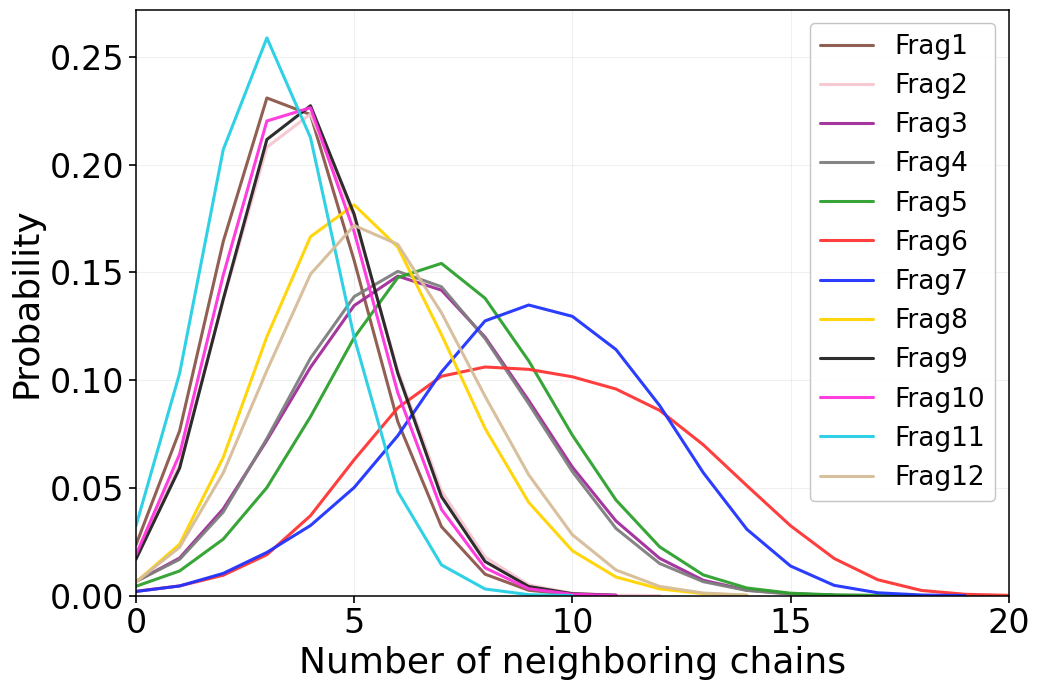

Saved: interaction_outputs_by_fragment/neighbor_probability_all_fragments_gaussian_smoothed.png
Saved: interaction_outputs_by_fragment/neighbor_probability_all_fragments_gaussian_smoothed.pdf


In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d


OUTPUT_DIR = Path("./interaction_outputs_by_fragment")

FRAGMENTS = range(1, 13)

CUTOFF_A = 5.0

# Use 20 to match your example.
# Set to None to use the maximum observed neighbor count.
X_MAX = 20

# Curve thickness
LINE_WIDTH = 2.2

# Gaussian smoothing strength, measured in neighbor-count bins:
# 0.5 = very light
# 0.8 = light
# 1.0–1.5 = stronger
GAUSSIAN_SIGMA = 0.8


FRAGMENT_COLORS = {
    1: "#8c564b",   # brown
    2: "#f7c6d0",   # light pink
    3: "#a02c9a",   # purple
    4: "#7f7f7f",   # gray
    5: "#2ca02c",   # green
    6: "#ff3333",   # red
    7: "#1f33ff",   # blue
    8: "#ffd400",   # yellow
    9: "#222222",   # black
    10: "#ff33dd",  # magenta
    11: "#25cfe3",  # cyan
    12: "#d6bd99",  # tan
}


fig, ax = plt.subplots(figsize=(10.5, 7.0))

maximum_observed = 0
number_loaded = 0


for fragment_id in FRAGMENTS:

    csv_file = (
        OUTPUT_DIR
        / f"Frag-{fragment_id}_neighbor_probability.csv"
    )

    if not csv_file.exists():
        print(
            f"Skipping Frag-{fragment_id}: "
            f"file not found: {csv_file}"
        )
        continue

    dataframe = pd.read_csv(csv_file)

    required_columns = {
        "neighbor_count",
        "probability",
    }

    missing_columns = required_columns.difference(
        dataframe.columns
    )

    if missing_columns:
        print(
            f"Skipping Frag{fragment_id}: "
            f"missing columns {sorted(missing_columns)}"
        )
        continue

    dataframe = (
        dataframe[
            ["neighbor_count", "probability"]
        ]
        .dropna()
        .sort_values("neighbor_count")
    )

    if dataframe.empty:
        print(
            f"Skipping Frag-{fragment_id}: "
            "no valid probability data"
        )
        continue

    x_values = dataframe["neighbor_count"].to_numpy(
        dtype=float
    )

    y_original = dataframe["probability"].to_numpy(
        dtype=float
    )

    # 
    
    # APPLY LIGHT GAUSSIAN SMOOTHING # ------------------------------------------------------------------------

    
    y_smoothed = gaussian_filter1d(
        y_original,
        sigma=GAUSSIAN_SIGMA,
        mode="nearest",
    )

    # Prevent tiny negative numerical values, if any.
    y_smoothed = np.clip(
        y_smoothed,
        0,
        None,
    )

    # Preserve the original total probability after smoothing.
    original_sum = y_original.sum()
    smoothed_sum = y_smoothed.sum()

    if original_sum > 0 and smoothed_sum > 0:
        y_smoothed *= original_sum / smoothed_sum

    maximum_observed = max(
        maximum_observed,
        int(x_values.max()),
    )

    ax.plot(
        x_values,
        y_smoothed,

        marker=None,
        linewidth=LINE_WIDTH,

        color=FRAGMENT_COLORS[fragment_id],
        label=f"Frag{fragment_id}",

        solid_capstyle="round",
        solid_joinstyle="round",

        alpha=0.95,
    )

    number_loaded += 1


if number_loaded == 0:
    raise FileNotFoundError(
        f"No fragment probability CSV files were found in:\n"
        f"{OUTPUT_DIR.resolve()}"
    )


if X_MAX is None:
    plot_x_max = maximum_observed + 1
else:
    plot_x_max = X_MAX




ax.set_xlabel(
    rf"Number of neighboring chains",
    fontsize=26,
)

ax.set_ylabel(
    "Probability",
    fontsize=26,
)

ax.set_xlim(
    0,
    plot_x_max,
)

ax.set_ylim(
    bottom=0,
)

ax.set_xticks(
    range(
        0,
        plot_x_max + 1,
        5,
    )
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=24,
    width=1.2,
    length=5,
)

ax.grid(
    True,
    alpha=0.18,
    linewidth=0.8,
)

for spine in ax.spines.values():
    spine.set_linewidth(1.1)


ax.legend(
    loc="upper right",
    fontsize=19,
    frameon=True,
    framealpha=0.90,
    edgecolor="0.75",
    ncol=1,
)


fig.tight_layout()


# -----------------------------------------------------------------------------
# SAVE FIGURES
# -----------------------------------------------------------------------------

png_file = (
    OUTPUT_DIR
    / "neighbor_probability_all_fragments_gaussian_smoothed.png"
)

pdf_file = (
    OUTPUT_DIR
    / "neighbor_probability_all_fragments_gaussian_smoothed.pdf"
)

fig.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    pdf_file,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved: {png_file}")
print(f"Saved: {pdf_file}")